In [30]:
import pandas as pd

# CSV-Dateien laden
df_seq = pd.read_csv("../../documentation/pdb_sequences_detailed.csv")
df_map = pd.read_csv("../../documentation/clean_entity_mapping.csv")

# Einheitliche PDB-IDs
df_seq["pdb_id"] = df_seq["pdb_id"].str.lower()
df_map["pdb"] = df_map["pdb"].str.lower()

# Nur relevante Spalten: Heavy Chains
df_map = df_map[["pdb", "H_entity_id", "heavy_subclass", "light_subclass"]]

# Typkonvertierung: entity_id als Integer (wenn nicht bereits)
df_seq["entity_id"] = df_seq["entity_id"].astype(int)
df_map = df_map[df_map["H_entity_id"].notna()]
df_map["H_entity_id"] = df_map["H_entity_id"].astype(int)

# Merge der Sequenzen mit den Genfamilien-Infos
merged = pd.merge(
    df_seq,
    df_map,
    how="left",
    left_on=["pdb_id", "entity_id"],
    right_on=["pdb", "H_entity_id"]
)

# Ausgabe speichern
merged.to_csv("pdb_sequences_with_subclasses.csv", index=False)
print(f"[INFO] Merge abgeschlossen. {merged['heavy_subclass'].notna().sum()} Heavy Chains mit Zuordnung.")

[INFO] Merge abgeschlossen. 2589 Heavy Chains mit Zuordnung.


In [31]:
import pandas as pd
from Bio import SeqIO, AlignIO
from Bio.Align import MultipleSeqAlignment
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio.Align.Applications import ClustalOmegaCommandline
from collections import Counter
import os
import tempfile

def extract_genfamily(seq_name):
    parts = seq_name.split('|')
    if len(parts) >= 3:
        return parts[2]
    return None

def consensus_from_alignment(alignment):
    consensus = []
    aln_length = alignment.get_alignment_length()
    for i in range(aln_length):
        column = alignment[:, i]
        most_common = Counter(column).most_common(1)[0][0]
        consensus.append(most_common)
    return "".join(consensus)

def run_clustalo(sequences, output_path):
    SeqIO.write(sequences, output_path + ".input.fasta", "fasta")

    clustalomega_cline = ClustalOmegaCommandline(
        infile=output_path + ".input.fasta",
        outfile=output_path + ".msa.fasta",
        verbose=True,
        force=True,
        auto=True,
    )
    clustalomega_cline()

    alignment = AlignIO.read(output_path + ".msa.fasta", "fasta")
    return alignment

def main():
    input_csv = "anarci_results.csv"
    output_dir = "msa_results"
    os.makedirs(output_dir, exist_ok=True)

    df = pd.read_csv(input_csv)

    df_human_h = df[df["domain_id"] == "human_H"].copy()
    df_human_h["genfamily"] = df_human_h["seq_name"].apply(extract_genfamily)

    consensus_results = []

    for genfamily, group in df_human_h.groupby("genfamily"):
        sequences = []
        for idx, row in group.iterrows():
            seq_id = row["seq_name"]
            seq = row["variable_region"]
            sequences.append(SeqRecord(Seq(seq), id=seq_id, description=""))

        if len(sequences) < 2:
            print(f"Nur eine Sequenz für Genfamilie {genfamily}, MSA übersprungen.")
            consensus_seq = str(sequences[0].seq)
            # Speichere die einzelne Sequenz als fasta auch
            single_seq_file = os.path.join(output_dir, f"msa_{genfamily}.msa.fasta")
            SeqIO.write(sequences, single_seq_file, "fasta")
        else:
            output_path = os.path.join(output_dir, f"msa_{genfamily}")
            alignment = run_clustalo(sequences, output_path)
            consensus_seq = consensus_from_alignment(alignment)

        consensus_results.append({"genfamily": genfamily, "consensus_sequence": consensus_seq})

    consensus_df = pd.DataFrame(consensus_results)
    consensus_csv_path = os.path.join(output_dir, "consensus_sequences_by_genfamily.csv")
    consensus_df.to_csv(consensus_csv_path, index=False)
    print(f"Konsensus-Sequenzen wurden gespeichert in {consensus_csv_path}")

if __name__ == "__main__":
    main()

Konsensus-Sequenzen wurden gespeichert in msa_results/consensus_sequences_by_genfamily.csv


In [39]:
import pandas as pd
import os
import subprocess

# Input-Datei
input_csv = "msa_results/consensus_sequences_by_genfamily.csv"

# Output-Ordner
output_dir = "msa_consensus_output"
os.makedirs(output_dir, exist_ok=True)

# Output-Dateien
fasta_file = os.path.join(output_dir, "consensus_sequences.fasta")
msa_output_file = os.path.join(output_dir, "consensus_msa.fasta")

# CSV einlesen
df = pd.read_csv(input_csv)

# Prüfen, ob nötige Spalten da sind
if not {'genfamily', 'consensus_sequence'}.issubset(df.columns):
    raise ValueError("CSV muss Spalten 'genfamily' und 'consensus_sequence' enthalten.")

# FASTA-Datei schreiben
with open(fasta_file, "w") as fasta:
    for _, row in df.iterrows():
        seq_id = row['genfamily'].split('|')[-1]  # z. B. IGHV5 aus 7ezv_entity2|H|IGHV5
        sequence = row['consensus_sequence']
        fasta.write(f">{seq_id}\n{sequence}\n")

# Clustal Omega ausführen
try:
    subprocess.run([
        "clustalo",
        "-i", fasta_file,
        "-o", msa_output_file,
        "--force", "--outfmt", "fasta"
    ], check=True)
    print(f"✅ MSA erfolgreich gespeichert unter: {msa_output_file}")
except subprocess.CalledProcessError:
    print("❌ Fehler beim Ausführen von Clustal Omega. Ist es korrekt installiert?")

Transfer:./hhalignment-C.h:3120: profile has no leading and/or trailing residues (h=0:t=-1:#=1)
Transfer:./hhalignment-C.h:3120: profile has no leading and/or trailing residues (h=-1:t=0:#=1)
✅ MSA erfolgreich gespeichert unter: msa_consensus_output/consensus_msa.fasta


FORCED DEBUG: Potential Problem: sequences (N=9) don't have same lengths but contain gaps, consider using --dealign


In [40]:
import subprocess

subprocess.run([
    "clustalo",
    "-i", "msa_consensus_output/consensus_msa.fasta",
    "--distmat-out", "msa_consensus_output/distance_matrix.txt",
    "--full",
    "--force"
])

>IGHV1
QVQLVQSGAEVKKPGASVKVSCKASGYTFTS--YAIHWVRQAPGQGLEWMGWINPIS-GN
TNYAQKFQGRVTITADTSTSTAYMELSSLRSEDTAVYYCARDYG-YYGFDYWGQGTLVTV
SSA
>IGHV14
EVQLQQSGAELVKPGASVKLSCKASGFNIKD--TYIHWVKQRPEQGLEWIGRIDPAN-SN
TIYDPKFQGKATITADTSSNTAYLQLSSLTSEDTAVYYCARGGFDHYAMDYWGQGTSVTV
SSA
>IGHV2
QITLKESGPTLVKPTQTLTLTCTFSGFSLSTSGVGVGWIRQPPGKALEWLALIYWDD--D
KRYSPSLKSRLTITKDTSKNQVVLTMTNMDPVDTATYYCAHHFI-PSIFDYWGQGTLVTV
SSA
>IGHV3
EVQLVESGGGLVQPGGSLRLSCAASGFTFSS--YYMHWVRQAPGKGLEWVSVISSDG-GS
TYYADSVKGRFTISRDNSKNTLYLQMNSLRAEDTAVYYCARDGY---GFDYWGQGTLVTV
SSA
>IGHV4
QVQLQESGPGLVKPSETLSLTCTVSGGSISS-GYYWSWIRQPPGKGLEWIGYIYYSG--S
TNYNPSLKSRVTISVDTSKNQFSLKLSSVTAADTAVYYCARDPR-GGGFDYWGQGTLVTV
SSA
>IGHV5
EVQLVQSGAEVKKPGESLKISCKGSGYSFTS--YWIGWVRQMPGKGLEWMGIIYPGD-SD
TRYSPSFQGQVTISADKSISTAYLQWSSLKASDTAMYYCARGGG-SGYFDYWGQGTLVTV
SSA
>IGHV6
QVQLQQSGPGLVKPSQTLSLTCAISGDSVSSNSAAWNWIRQSPSRGLEWLGRTYYRSKWY
NDYAVSVKSRITINPDTSKNQFSLQLNSVTPEDTAVYYCARED--YYGFDYWGQGTLVTV
SSA
>IGHV7
QVQLVQSGSELKKPGASVKVSCKASGYTFTS--YAMNWVRQAPGQGLEWMGWINTNT-GE


CompletedProcess(args=['clustalo', '-i', 'msa_consensus_output/consensus_msa.fasta', '--distmat-out', 'msa_consensus_output/distance_matrix.txt', '--full', '--force'], returncode=0)

PTYAQGFTGRFVFSLDTSVSTAYLQISSLKAEDTAVYYCAREG----WFDYWGQGTLVTV
SS-
>IGHV9
QIQLVQSGPELKKPGETVKISCKASGYTFTD--YGVIWVKQAPGKALKWMGWINTYT-GE
PTYADDLKGRFAFSLETSASSASLQINNLKNEDTATYFCARRYG-PEDIDYWGQGTTLTV
SSA


In [44]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram, to_tree
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
from io import StringIO

# 1. Distance Matrix einlesen
file_path = "msa_consensus_output/distance_matrix.txt"

with open(file_path, "r") as f:
    lines = f.readlines()

# Anzahl der Sequenzen
n = int(lines[0].strip())

# Labels und Matrix extrahieren
labels = []
matrix = []

for line in lines[1:]:
    parts = line.strip().split()
    label = parts[0]
    values = list(map(float, parts[1:]))
    labels.append(label)
    matrix.append(values)

# 2. In ein DataFrame umwandeln
df = pd.DataFrame(matrix, index=labels, columns=labels)

# 3. In ein condensed Distance Array umwandeln (für linkage)
condensed_dist = squareform(df.values)

# 4. Hierarchisches Clustering (z.B. UPGMA / average linkage)
Z = linkage(condensed_dist, method='average')

# 5. Dendrogramm zeichnen
plt.figure(figsize=(10, 6))
dendrogram(Z, labels=labels, leaf_rotation=90)
plt.title("Phylogenetischer Baum (UPGMA) der Genfamilien")
plt.xlabel("Genfamilie")
plt.ylabel("Distanz")
plt.tight_layout()
plt.savefig("msa_consensus_output/consensus_tree.png")
plt.show()

ModuleNotFoundError: No module named 'numpy.char'

In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 📂 Speicherort definieren
output_folder = "heatmap_output"
os.makedirs(output_folder, exist_ok=True)

# 🔄 Pfad zur Distanzmatrix anpassen
distance_matrix_path = "msa_consensus_output/distance_matrix.txt"

# 📥 Matrix einlesen
df = pd.read_csv(distance_matrix_path, sep="\t", index_col=0)

# 🔢 Optional: Sicherstellen, dass alle Werte numerisch sind
df = df.apply(pd.to_numeric, errors='coerce')

# 📊 Heatmap erstellen
plt.figure(figsize=(10, 8))
sns.heatmap(df, cmap="viridis", annot=True, fmt=".2f", square=True, cbar_kws={"label": "Distance"})
plt.title("Sequence Distance Heatmap")
plt.tight_layout()

# 💾 Speichern
heatmap_file = os.path.join(output_folder, "distance_heatmap.png")
plt.savefig(heatmap_file, dpi=300)
plt.show()

print(f"✅ Heatmap gespeichert unter: {heatmap_file}")

ValueError: zero-size array to reduction operation fmin which has no identity

<Figure size 1000x800 with 0 Axes>

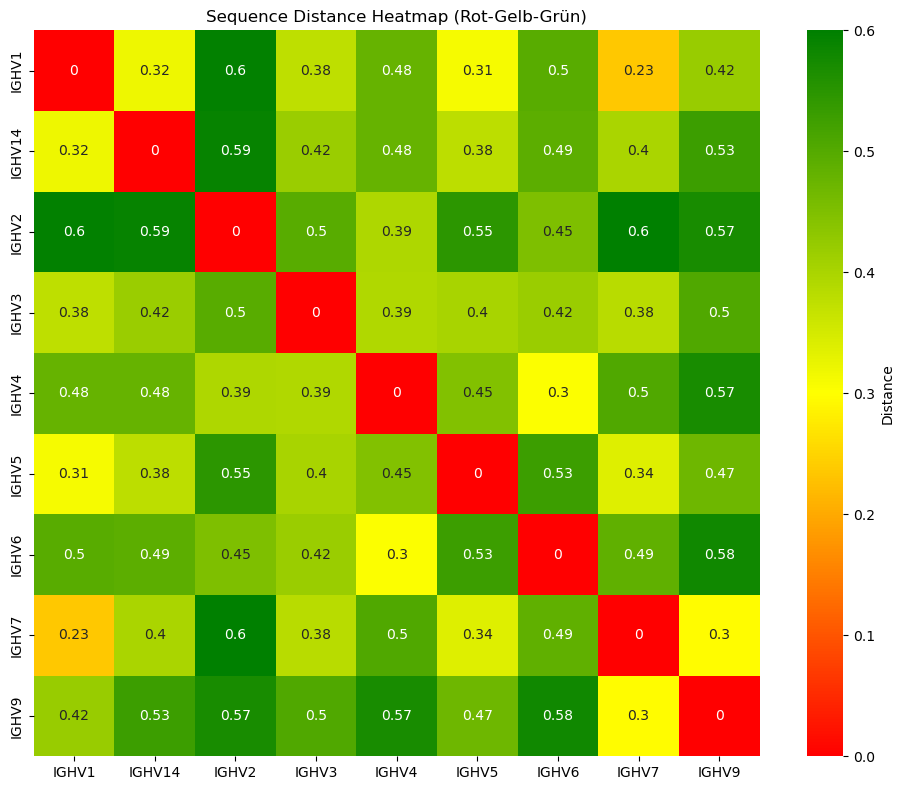

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Beispiel: df_matrix ist deine Distanzmatrix als DataFrame

# Farbskala definieren: Rot (low) -> Gelb (mid) -> Grün (high)
colors = ["red", "yellow", "green"]
cmap = LinearSegmentedColormap.from_list("red_yellow_green", colors)

plt.figure(figsize=(10, 8))
sns.heatmap(df_matrix, annot=True, cmap=cmap, square=True, cbar_kws={"label": "Distance"})
plt.title("Sequence Distance Heatmap (Rot-Gelb-Grün)")
plt.tight_layout()
plt.show()